## Basic LMS (learn a simple signal)

In [ ]:
!pip install padasip

  Preparing metadata (setup.py) ... done
  Created wheel for padasip: filename=padasip-1.2.2-py3-none-any.whl size=51651 sha256=0eb5107bf7187feb07bdd418bca36032265d4a8c3e769ad2f58dc73c78273812
  Stored in directory: /root/.cache/pip/wheels/3c/7f/ab/47aa5c180926b9428846d51b1591aa193bb6cc27ad885befca
Successfully built padasip


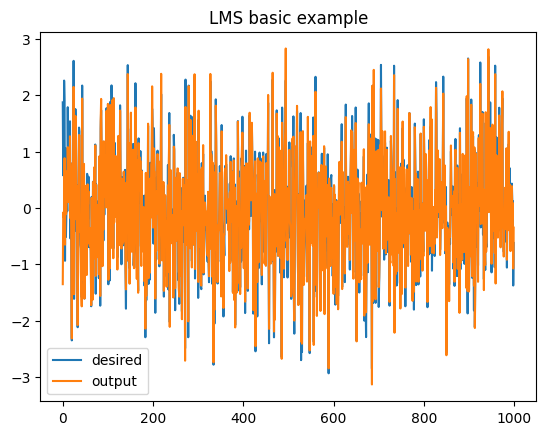

In [ ]:
import numpy as np
import padasip as pa
import matplotlib.pyplot as plt

# signal
np.random.seed(0)
x = np.random.randn(1000, 1)

# desired = signal + noise
d = x.flatten() + 0.2*np.random.randn(1000)

# LMS filter
f = pa.filters.FilterLMS(n=1, mu=0.1)

y, e, w = f.run(d, x)

plt.plot(d, label="desired")
plt.plot(y, label="output")
plt.legend()
plt.title("LMS basic example")
plt.show()

## Ejemplo 2

In [ ]:
f1=5 # hz
fs = 1e3 # 1khz

t = np.linspace(0,4,int(4*fs))

w1 = 2*np.pi*f1

s = np.sin(w*t)
Ns = len(s)

f2 = 0.2
w2 = 2*np.pi*f2
wander = 0.5*np.sin(w2*t)
x = s + wander


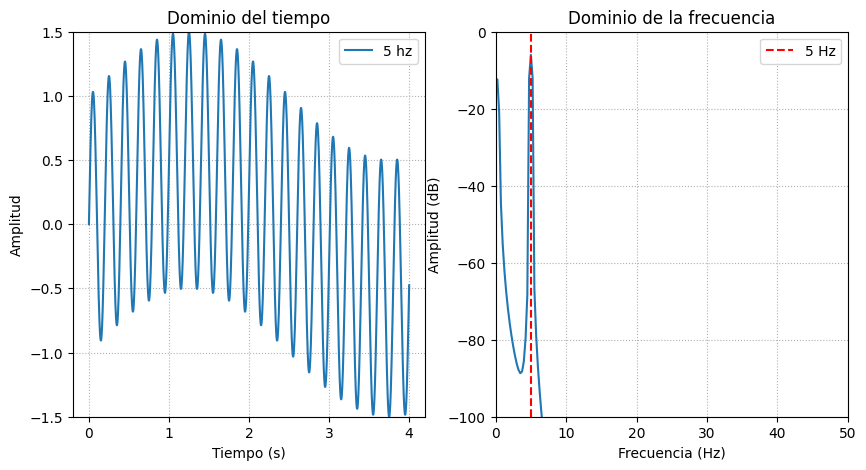

In [ ]:
# @title Gráfica en el dominio del tiempo
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Dominio del tiempo")
plt.plot(t,x, label=f"{f} hz")
plt.grid(ls=":")
plt.ylim(-1.5, 1.5)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.title("Dominio de la frecuencia")
plt.magnitude_spectrum(x,Fs=fs, scale="dB")
plt.grid(ls=":")
plt.xlim(0,50)
plt.ylim(-100,0)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud (dB)")
# marcar frecuencia de interés
plt.axvline(x=f, color='red', linestyle='--', label=f'{f} Hz')
plt.legend()

plt.show()

# align signals
t_aligned = t[M:]

plt.plot(t, x, label="original")
plt.plot(t_aligned, e, label="cleaned (error)")
plt.legend()
plt.show()

(3997, 4) (3997,)


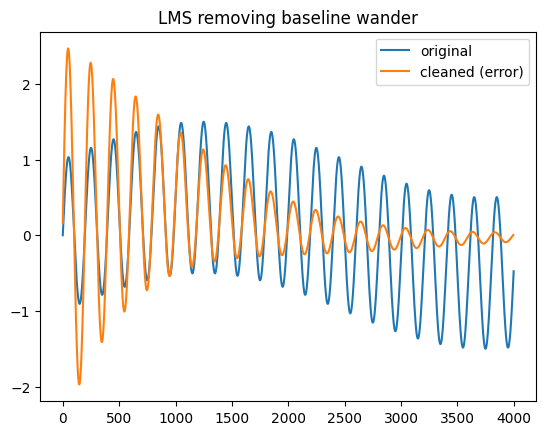

In [ ]:
M = 4

X = pa.input_from_history(x, M)

d = x[M-1:] # Corrected to align length with X

print(X.shape, d.shape)  # deben coincidir

f = pa.filters.FilterNLMS(n=M, mu=0.001, w="random")
y, e, w = f.run(d, X)

plt.plot(x, label="original")
plt.plot(e, label="cleaned (error)")
plt.legend()
plt.title("LMS removing baseline wander")
plt.show()

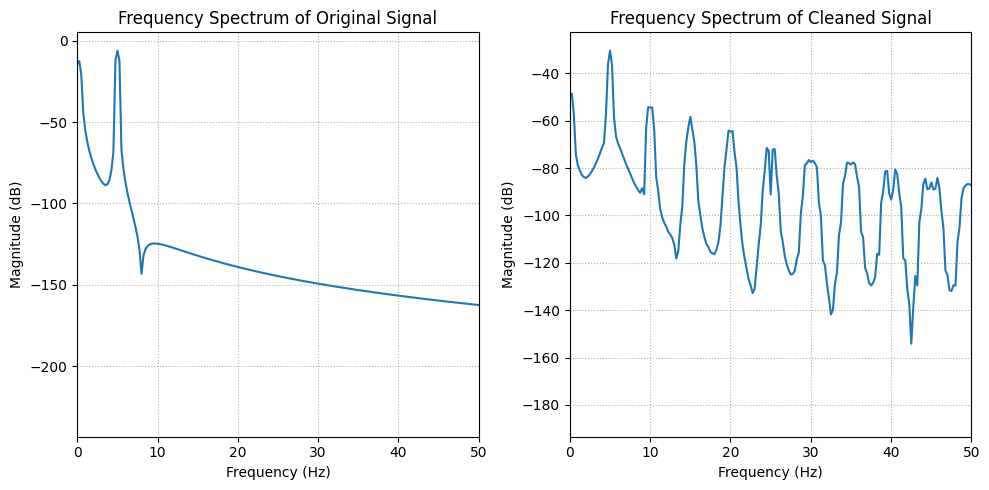

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Frequency Spectrum of Original Signal")
plt.magnitude_spectrum(x, Fs=fs, scale="dB")
plt.grid(ls=":")
plt.xlim(0, 50) # Assuming frequencies of interest are below 50 Hz
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")

plt.subplot(1, 2, 2)
plt.title("Frequency Spectrum of Cleaned Signal")
plt.magnitude_spectrum(e, Fs=fs, scale="dB")
plt.grid(ls=":")
plt.xlim(0, 50) # Assuming frequencies of interest are below 50 Hz
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")

plt.tight_layout()
plt.show()

### Signal-to-Noise Ratio (SNR) Calculation

To quantify the effectiveness of the LMS filter in removing the baseline wander, we will calculate the Signal-to-Noise Ratio (SNR) for both the original signal (`x`) and the cleaned signal (`e`).

The SNR is defined as:

$$ \text{SNR}_{dB} = 10 \log_{10} \left( \frac{P_{signal}}{P_{noise}} \right) $$

Where $P_{signal}$ is the power of the desired signal and $P_{noise}$ is the power of the noise.

In this context:
- For the **original signal (`x`)**: The desired signal is `s` (the 5Hz sine wave), and the noise is `wander` (the 0.2Hz baseline wander).
- For the **cleaned signal (`e`)**: The desired signal is still `s`, and the noise is the residual error, which is the difference between the cleaned signal `e` and the desired signal `s` ($e - s$).

We need to ensure that `s` and `wander` are properly aligned and truncated to match the length of `e` for accurate comparison.

In [ ]:
# Helper function for SNR calculation
def calculate_snr(signal_power, noise_power):
    if noise_power == 0:
        return float('inf') # Avoid division by zero if noise is perfectly removed
    return 10 * np.log10(signal_power / noise_power)

# Reference signal (pure sine wave) and noise (baseline wander) aligned with 'e'
# 'e' has a length of len(x) - M + 1 (i.e., 3991 elements)
# So, s_ref and wander_ref should also be truncated to this length.
s_ref = s[M-1:]
wander_ref = wander[M-1:]

# Calculate SNR for the original signal (x_ref = s_ref + wander_ref)
signal_power_original = np.mean(s_ref**2)
noise_power_original = np.mean(wander_ref**2)
snr_original = calculate_snr(signal_power_original, noise_power_original)

# Calculate SNR for the cleaned signal (e)
# Here, 'e' is ideally 's_ref', so the noise is the difference (e - s_ref)
signal_power_cleaned = np.mean(s_ref**2)
noise_power_cleaned = np.mean((e - s_ref)**2)
snr_cleaned = calculate_snr(signal_power_cleaned, noise_power_cleaned)

print(f"SNR of Original Signal: {snr_original:.2f} dB")
print(f"SNR of Cleaned Signal: {snr_cleaned:.2f} dB")

SNR of Original Signal: 5.77 dB
SNR of Cleaned Signal: -0.06 dB


### Adjusting the Learning Rate ($\mu$)

The learning rate ($\mu$) is a crucial parameter in the LMS algorithm. It controls the step size taken to adjust the filter weights in each iteration.

*   **A larger $\mu$** leads to faster convergence but can result in instability and larger steady-state error (overshooting the optimal weights).
*   **A smaller $\mu$** leads to slower convergence but generally results in more stable adaptation and smaller steady-state error.

We will try a different value for $\mu$ (e.g., `0.05`) and observe its effect on the SNR.

Rerunning LMS filter with mu = 0.05
SNR of Cleaned Signal (new mu = 0.05): -0.01 dB


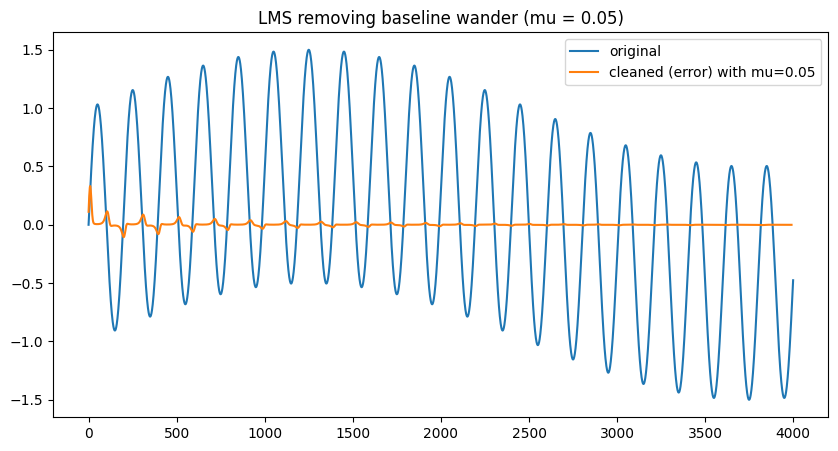

In [ ]:
# Try a new learning rate (mu)
new_mu = 0.05 # You can experiment with different values here

print(f"Rerunning LMS filter with mu = {new_mu}")

f_new = pa.filters.FilterLMS(n=M, mu=new_mu)
y_new, e_new, w_new = f_new.run(d, X)

# Recalculate SNR for the cleaned signal with new mu
noise_power_cleaned_new = np.mean((e_new - s_ref)**2)
snr_cleaned_new = calculate_snr(signal_power_cleaned, noise_power_cleaned_new)

print(f"SNR of Cleaned Signal (new mu = {new_mu}): {snr_cleaned_new:.2f} dB")

# Plot the new cleaned signal
plt.figure(figsize=(10, 5))
plt.plot(x, label="original")
plt.plot(e_new, label=f"cleaned (error) with mu={new_mu}")
plt.legend()
plt.title(f"LMS removing baseline wander (mu = {new_mu})")
plt.show()